# Do Kalshi MLB Game Winner Prices Reflect Accurate Probabilities?
If a YES contract trades at 45c just before first pitch, does that team win 45% of the time?

## Method
Compare Kalshi prices to (empirical) probabilities from observed historical data.\
Note on terminology. If the prices match the probabilities we say the market is calibrated.

### Data Points
Each game contributes a single data point.\
Which is the last trade on its home team's market before the scheduled start.\
Note
- using a single data point per game avoids a problem of being overconfident by having a large sample size of highly correlated trades happening right next to each other
- restricted to the 24 hours before start, so stale quotes don't leak in
- For by inning view we use the last trade during the preceding inning. ie the price entering that inning

### Chart and Table Presentation
Data is displayed in price buckets. For different cuts.\
A cut is simply a way to break down the data in different ways by filtering on things such as team or weather.
- 10c buckets for every cut

## Data
Data has been pulled from the official Kalshi API and MLB Stats API.\
An extensive write up on this data pull can be seen xxxxxxx.

The data date range is from\
April 16th 2025 - July 3rd 2026.\
This date range was chosen because Kalshi MLB markets started trading April 16th 2025, and I ran the last data pull on July 3rd 2026.\
The data covers 3,507 games.\
Note
- The 2025 MLB season started March 27th 2025
    - So we are missing ~3 weeks of data from the 2025 season.

## Potential Profit??????
If prices are off, there is money to be made.\
A team priced at 45c that actually wins 50% of the time earns 5c per contract on average.

But Kalshi charges a taker fee of 7c × price × (1 − price), about 1.7c per contract at 45c.\
So a mispricing has to be bigger than the fee before it is profit.

## Setup
### Import Libraries

In [1]:
%matplotlib inline
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import polars as pl
from IPython.display import Markdown, display

### Connect To DB

In [2]:
con = duckdb.connect(Path("../db/pma.db"), read_only=True)

con.sql("""
    CREATE OR REPLACE TEMP VIEW pre_home AS
    SELECT * FROM mlb_calib_pre_snapshots WHERE side = 'home'
""")

### Chart Style
Colors and matplotlib params.\
Just for aesthetics

In [3]:
# palette = the zh_init site's light theme (zh_init/src/index.css)
GREEN = "#3d7356"    # series 1: site accent, green-600
CLAY = "#c2703d"    # series 2: terracotta, warm counterpart to the green
INK = "#1c1c1a"      # gray-900, text
MUTED = "#6e6e6c"    # gray-500, secondary text
GRID = "#ededeb"     # gray-100, subtle border
BASELINE = "#d9d9d7" # gray-200, border
SURFACE = "#fafaf8"  # site background

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.labelcolor": MUTED,
    "text.color": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "figure.dpi": 110,
})

### Stats Helper Functions
Wilson confidence interval is used because prices (and probabilities) lie between 0 and 1\
and Wilson is designed specifically to stay in this range.

with_deviation returns the tables that you will see across this analysis

In [4]:
def wilson(p_hat, n, z=1.96):
    """Wilson score interval for a proportion phat observed over n trials."""
    p_hat = np.asarray(p_hat, dtype=float)
    n = np.asarray(n, dtype=float)
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half


def with_deviation(df):
    """Deviation (win rate − avg price) with a 95% CI:
    the Wilson interval on the win rate,
    shifted by the average price."""
    lo, hi = wilson(df["win_rate"].to_numpy(), df["n_samples"].to_numpy())
    return df.with_columns(
        pl.Series("ci_lo", lo),
        pl.Series("ci_hi", hi),
        (pl.col("win_rate") - pl.col("avg_price")).alias("deviation"),
        (pl.Series(lo) - pl.col("avg_price")).alias("dev_lo"),
        (pl.Series(hi) - pl.col("avg_price")).alias("dev_hi"),
    )

### Query Helper Functions
Two query shapes cover every cut.
- `calibration` buckets snapshots by price. One row per bucket
- `group_deviation` groups them by anything else (team, side, weather). One row per group

Both return the deviation table from the stats helpers.

In [5]:
def calibration(rel="pre_home", where="TRUE", buckets=10, params=None):
    """Calibration table over price buckets: one snapshot = one observation."""
    df = con.execute(f"""
        SELECT least(floor(p * {buckets}), {buckets - 1})::INT AS bucket,
               avg(p) AS avg_price,
               avg(y) AS win_rate,
               count(*) AS n_samples
        FROM {rel}
        WHERE {where}
        GROUP BY bucket ORDER BY bucket
    """, params).pl()
    return with_deviation(df)


def group_deviation(rel, expr, where="TRUE", order_by="grp"):
    """Aggregate deviation by a grouping expression: one row per group."""
    df = con.sql(f"""
        SELECT {expr} AS grp,
               count(*) AS n_samples,
               avg(p) AS avg_price,
               avg(y) AS win_rate
        FROM {rel}
        WHERE {where}
        GROUP BY grp ORDER BY {order_by}
    """).pl()
    return with_deviation(df)

### Plot Helper Function
Plots calibration curves seen throughout analysis

In [6]:
def plot_calibration(ax, df, color=GREEN, label=None):
    """Calibration curve with Wilson error bars and the 45-degree line."""
    ax.plot([0, 1], [0, 1], ls="--", lw=1, color=BASELINE, zorder=1)
    x = df["avg_price"].to_numpy()
    y = df["win_rate"].to_numpy()
    yerr = np.vstack([y - df["ci_lo"].to_numpy(),
                      df["ci_hi"].to_numpy() - y])
    ax.errorbar(x, y, yerr=yerr, fmt="o-", ms=3.5, lw=1.5, color=color,
                elinewidth=1, capsize=2, label=label, zorder=3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")


PCT = mtick.PercentFormatter(xmax=1, decimals=0)
# prices tick in cents, probabilities in percent, so the axes are
# tellable at a glance without reading the labels
CENTS = mtick.FuncFormatter(lambda p, _: f"{p * 100:.0f}¢")

### Table Helper Functions and Formatter Functions

In [7]:
pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(60)


def fmt_count(col):
    """Thousands-separated integer column."""
    return pl.col(col).map_elements(lambda n: f"{n:,}", return_dtype=pl.String)


def fmt_cents(col):
    return pl.format("{}¢", (pl.col(col) * 100).round(1))


def fmt_pct(col):
    return pl.format("{}%", (pl.col(col) * 100).round(1))


def fmt_signed_cents(col):
    v = (pl.col(col) * 100).round(1)
    return (pl.when(v > 0).then(pl.format("+{}¢", v))
              .when(v < 0).then(pl.format("{}¢", v))
              .otherwise(pl.lit("+0.0¢")))  # catches -0.0


def show_table(df, first):
    """The standard table: a name column, then the same columns everywhere."""
    return df.select(
        first,
        fmt_cents("avg_price").alias("avg price"),
        fmt_pct("win_rate").alias("win rate"),
        fmt_signed_cents("deviation").alias("win − price"),
        pl.format("[{}¢, {}¢]",
                  (pl.col("dev_lo") * 100).round(1),
                  (pl.col("dev_hi") * 100).round(1))
            .alias("95% CI (win − price)"),
        fmt_count("n_samples").alias("samples"),
    )


def show_calibration(df, buckets=10):
    """Standard table for a bucketed calibration table."""
    step = 100 // buckets
    lo = pl.col("bucket") * step
    return show_table(
        df, pl.format("{}–{}¢", lo, lo + step).alias("price range"))


def show_group(df, name_col):
    """Standard table for a grouped deviation table."""
    return show_table(df, pl.col(name_col))

## Cut 1 - Overall View

One datapoint per game\
the home-side market just before first pitch.\
Note
- pre-game MLB prices live almost entirely between 25c and 75c.
- so the tails of this curve are nearly empty

In [8]:
overall = calibration()
show_calibration(overall)

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""0–10¢""","""1.6¢""","""0.0%""","""-1.6¢""","""[-1.6¢, 41.8¢]""","""5"""
"""20–30¢""","""27.8¢""","""38.1%""","""+10.3¢""","""[-7.1¢, 31.3¢]""","""21"""
"""30–40¢""","""36.3¢""","""36.7%""","""+0.4¢""","""[-6.3¢, 7.6¢]""","""180"""
"""40–50¢""","""45.4¢""","""48.5%""","""+3.1¢""","""[-0.1¢, 6.4¢]""","""892"""
"""50–60¢""","""54.5¢""","""53.7%""","""-0.9¢""","""[-3.4¢, 1.6¢]""","""1,532"""
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717"""
"""70–80¢""","""72.6¢""","""73.1%""","""+0.4¢""","""[-7.0¢, 6.8¢]""","""156"""
"""80–90¢""","""80.0¢""","""100.0%""","""+20.0¢""","""[-45.8¢, 20.0¢]""","""2"""
"""90–100¢""","""99.0¢""","""100.0%""","""+1.0¢""","""[-64.8¢, 1.0¢]""","""2"""


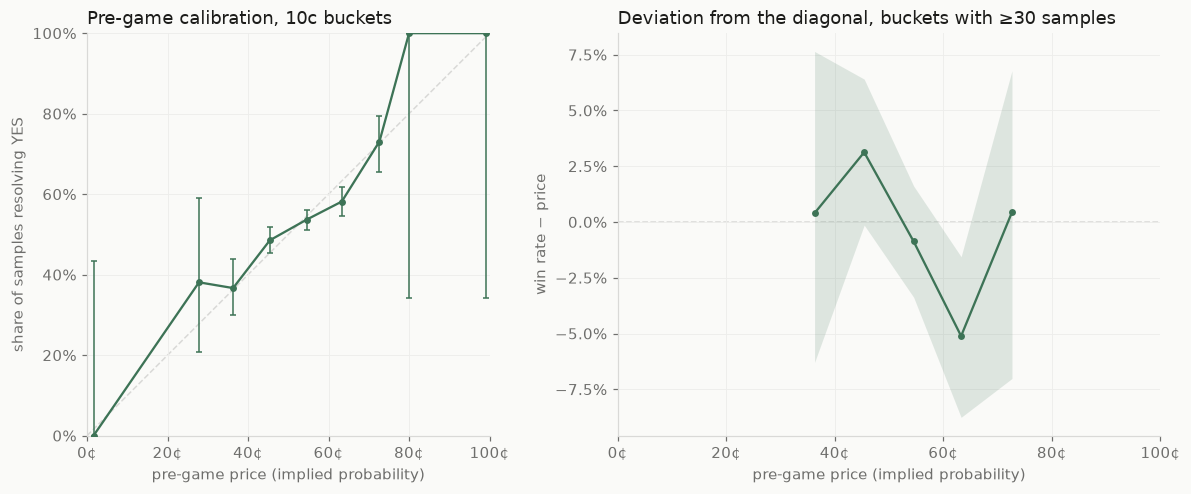

In [9]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1, 1.3]})

plot_calibration(ax1, overall)
ax1.set_xlabel("pre-game price (implied probability)")
ax1.set_ylabel("share of samples resolving YES")
ax1.set_title("Pre-game calibration, 10c buckets", color=INK)
ax1.xaxis.set_major_formatter(CENTS)
ax1.yaxis.set_major_formatter(PCT)

dense = overall.filter(pl.col("n_samples") >= 30)
x = dense["avg_price"].to_numpy()
dev = dense["deviation"].to_numpy()
lo = dense["dev_lo"].to_numpy()
hi = dense["dev_hi"].to_numpy()
ax2.axhline(0, ls="--", lw=1, color=BASELINE, zorder=1)
ax2.fill_between(x, lo, hi, color=GREEN, alpha=0.15, lw=0, zorder=2)
ax2.plot(x, dev, "o-", ms=3.5, lw=1.5, color=GREEN, zorder=3)
ax2.set_xlim(0, 1)
ax2.set_xlabel("pre-game price (implied probability)")
ax2.set_ylabel("win rate − price")
ax2.set_title("Deviation from the diagonal, buckets with ≥30 samples", color=INK)
ax2.xaxis.set_major_formatter(CENTS)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

fig.tight_layout()
plt.show()

In [10]:
# buckets whose 95% CI on win − price excludes zero
significant_buckets = overall.filter((pl.col("dev_lo") > 0) | (pl.col("dev_hi") < 0))
show_calibration(significant_buckets)

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717"""


### Opportunities?
There is one bucket where the CI for the "win rate - price" does not contain 0.\
This could potentially mean there is profit to be made here.

If we take a step back and think about this though, it seems fairly random that just one bucket from 60c-70c would be mispriced.\
Ie, why would 60c-70c be mispriced but 50-60c and 70-80c be well calibrated?\
Is there a logical reason for this, or are we looking at noise?

It would make more sense if we saw something like an asymmetric mispricing, like anything above 60c is mispriced in the same direction. Maybe when a team is highly likely to win it distorts people's perceptions and they overestimate that probability based on emotions.

My read at this point is that this is likely just noise.

## Cut 2 - Breakdown by inning

The pre-game panel repeats Cut 1.\
The rest show the price entering innings 2-9 and extras (entering the 10th).

In [11]:
INNINGS = (["pre-game"]
          + [f"inning {i}" for i in range(2, 10)]
          + ["extras"])


def inning_calibration(inning, buckets=10):
    if inning == "pre-game":
        return calibration(buckets=buckets)
    if inning == "extras":
        return calibration("mlb_calib_inning_snapshots",
                           "side = 'home' AND entering = 10",
                           buckets=buckets)
    return calibration("mlb_calib_inning_snapshots",
                       "side = 'home' AND entering = ?",
                       buckets=buckets,
                       params=[int(inning.split()[1])])


for inning in INNINGS:
    df = inning_calibration(inning)
    display(Markdown(f"**{inning}**, {df['n_samples'].sum():,} samples"))
    display(show_calibration(df, buckets=10))

**pre-game**, 3,507 samples

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""0–10¢""","""1.6¢""","""0.0%""","""-1.6¢""","""[-1.6¢, 41.8¢]""","""5"""
"""20–30¢""","""27.8¢""","""38.1%""","""+10.3¢""","""[-7.1¢, 31.3¢]""","""21"""
"""30–40¢""","""36.3¢""","""36.7%""","""+0.4¢""","""[-6.3¢, 7.6¢]""","""180"""
"""40–50¢""","""45.4¢""","""48.5%""","""+3.1¢""","""[-0.1¢, 6.4¢]""","""892"""
"""50–60¢""","""54.5¢""","""53.7%""","""-0.9¢""","""[-3.4¢, 1.6¢]""","""1,532"""
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717"""
"""70–80¢""","""72.6¢""","""73.1%""","""+0.4¢""","""[-7.0¢, 6.8¢]""","""156"""
"""80–90¢""","""80.0¢""","""100.0%""","""+20.0¢""","""[-45.8¢, 20.0¢]""","""2"""
"""90–100¢""","""99.0¢""","""100.0%""","""+1.0¢""","""[-64.8¢, 1.0¢]""","""2"""


**inning 2**, 3,494 samples

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""0–10¢""","""7.0¢""","""15.0%""","""+8.0¢""","""[-1.8¢, 29.0¢]""","""20"""
"""10–20¢""","""15.9¢""","""12.5%""","""-3.4¢""","""[-9.4¢, 6.9¢]""","""64"""
"""20–30¢""","""24.9¢""","""21.4%""","""-3.5¢""","""[-9.4¢, 4.1¢]""","""140"""
"""30–40¢""","""35.4¢""","""34.6%""","""-0.8¢""","""[-5.8¢, 4.6¢]""","""321"""
"""40–50¢""","""45.2¢""","""45.0%""","""-0.1¢""","""[-3.8¢, 3.6¢]""","""684"""
"""50–60¢""","""54.5¢""","""55.1%""","""+0.6¢""","""[-2.4¢, 3.7¢]""","""1,034"""
"""60–70¢""","""64.1¢""","""59.3%""","""-4.8¢""","""[-8.6¢, -1.0¢]""","""649"""
"""70–80¢""","""73.6¢""","""69.0%""","""-4.6¢""","""[-9.7¢, -0.0¢]""","""348"""
"""80–90¢""","""84.0¢""","""86.4%""","""+2.4¢""","""[-3.2¢, 6.5¢]""","""191"""
"""90–100¢""","""92.8¢""","""86.0%""","""-6.8¢""","""[-20.1¢, 0.6¢]""","""43"""


**inning 3**, 3,486 samples

...

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""0–10¢""","""3.7¢""","""3.1%""","""-0.6¢""","""[-1.6¢, 0.8¢]""","""782"""
"""10–20¢""","""13.3¢""","""11.4%""","""-1.9¢""","""[-5.0¢, 2.2¢]""","""298"""
"""20–30¢""","""24.2¢""","""26.6%""","""+2.4¢""","""[-2.2¢, 7.6¢]""","""312"""
"""30–40¢""","""32.9¢""","""30.9%""","""-2.0¢""","""[-12.6¢, 11.1¢]""","""55"""
"""40–50¢""","""46.5¢""","""47.3%""","""+0.7¢""","""[-7.7¢, 9.3¢]""","""129"""
"""50–60¢""","""53.9¢""","""52.7%""","""-1.2¢""","""[-7.8¢, 5.2¢]""","""224"""
"""60–70¢""","""63.8¢""","""73.3%""","""+9.5¢""","""[-4.8¢, 20.2¢]""","""45"""
"""70–80¢""","""75.7¢""","""78.2%""","""+2.5¢""","""[-3.4¢, 7.4¢]""","""225"""
"""80–90¢""","""84.7¢""","""83.2%""","""-1.5¢""","""[-6.1¢, 2.2¢]""","""315"""
"""90–100¢""","""96.2¢""","""96.7%""","""+0.5¢""","""[-0.8¢, 1.4¢]""","""1,064"""


**inning 9**, 3,399 samples

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""0–10¢""","""3.2¢""","""2.5%""","""-0.7¢""","""[-1.4¢, 0.5¢]""","""1,071"""
"""10–20¢""","""14.6¢""","""16.7%""","""+2.1¢""","""[-1.5¢, 6.6¢]""","""323"""
"""20–30¢""","""22.3¢""","""15.2%""","""-7.1¢""","""[-15.6¢, 8.7¢]""","""33"""
"""30–40¢""","""32.8¢""","""25.0%""","""-7.8¢""","""[-28.2¢, 37.2¢]""","""4"""
"""40–50¢""","""46.5¢""","""48.2%""","""+1.6¢""","""[-7.5¢, 10.9¢]""","""110"""
"""50–60¢""","""53.4¢""","""48.8%""","""-4.6¢""","""[-11.3¢, 2.1¢]""","""211"""
"""60–70¢""","""63.0¢""","""59.1%""","""-3.9¢""","""[-24.2¢, 13.8¢]""","""22"""
"""70–80¢""","""77.4¢""","""85.7%""","""+8.4¢""","""[-17.3¢, 18.6¢]""","""14"""
"""80–90¢""","""86.0¢""","""87.1%""","""+1.0¢""","""[-3.3¢, 4.4¢]""","""294"""
"""90–100¢""","""97.3¢""","""97.9%""","""+0.6¢""","""[-0.3¢, 1.3¢]""","""1,317"""


**extras**, 302 samples

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""30–40¢""","""37.7¢""","""66.7%""","""+29.0¢""","""[-16.9¢, 56.2¢]""","""3"""
"""40–50¢""","""46.4¢""","""50.4%""","""+4.0¢""","""[-5.1¢, 13.1¢]""","""113"""
"""50–60¢""","""53.4¢""","""52.3%""","""-1.1¢""","""[-8.5¢, 6.2¢]""","""172"""
"""60–70¢""","""62.4¢""","""41.7%""","""-20.7¢""","""[-43.0¢, 5.7¢]""","""12"""
"""70–80¢""","""77.0¢""","""100.0%""","""+23.0¢""","""[-56.3¢, 23.0¢]""","""1"""
"""80–90¢""","""86.0¢""","""100.0%""","""+14.0¢""","""[-65.3¢, 14.0¢]""","""1"""


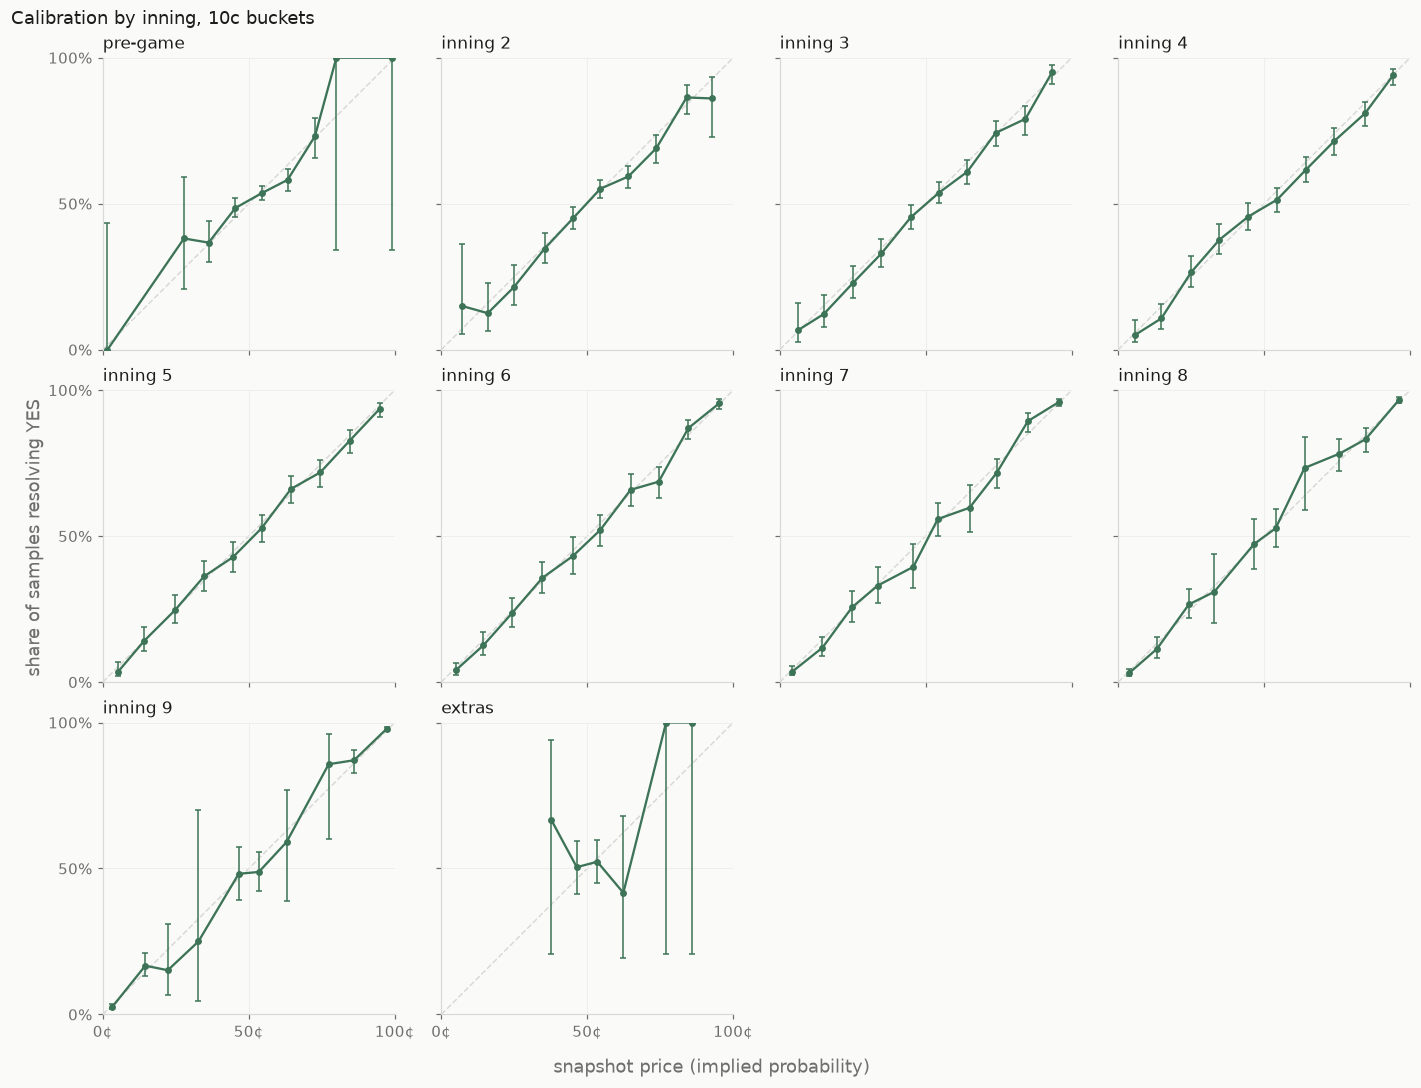

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(13, 10), sharex=True, sharey=True)

for ax, inning in zip(axes.flat, INNINGS):
    df = inning_calibration(inning)
    plot_calibration(ax, df)
    ax.set_title(inning, color=INK, fontsize=11)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(CENTS)
    ax.yaxis.set_major_formatter(PCT)

for ax in axes.flat[len(INNINGS):]:
    ax.set_visible(False)
fig.supxlabel("snapshot price (implied probability)", color=MUTED)
fig.supylabel("share of samples resolving YES", color=MUTED)
fig.suptitle("Calibration by inning, 10c buckets", color=INK, x=0.01,
             ha="left")
fig.tight_layout()
plt.show()

### A Note on Sample Distribution
We can get a visual understanding of the sample distribution by looking at the width of the CI bands. In the plots above we observe 
- pre-game
    - samples are concentrated between 40c to 60c
    - ie prior to the game it's hard to know who will win
- during the beginning and middle of the game
    - samples are fairly evenly spread across buckets
    - ie one team could take the lead causing probabilities to skew towards either side
- and towards the end of the game
    - samples are concentrated at prices in the middle and at the ends
    - ie if the score is close either team could win it, or one team has a lead and will likely win

### Opportunities
Markets appear to be well calibrated throughout the game.

## Cut 3 - Home vs Away
A home team bias would show up here.

Pre-game datapoints split by whether the market's YES team is the home team.\
For this cut there are 2 data points for each game. One for each team.

In [13]:
sides = (group_deviation("mlb_calib_pre_snapshots", "side")
         .rename({"grp": "side"}))
show_group(sides, "side")

side,avg price,win rate,win − price,95% CI (win − price),samples
"""away""","""47.5¢""","""46.8%""","""-0.6¢""","""[-2.3¢, 1.0¢]""","""3,507"""
"""home""","""53.7¢""","""53.2%""","""-0.5¢""","""[-2.2¢, 1.1¢]""","""3,507"""


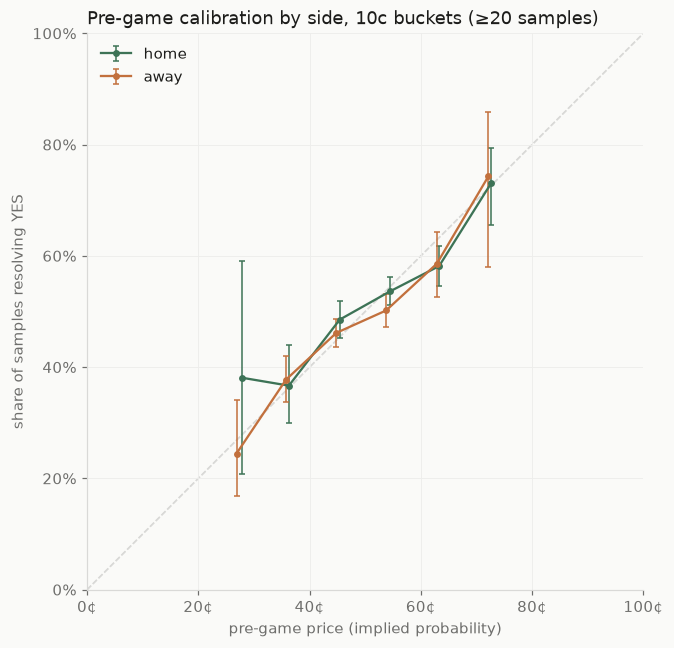

In [14]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))

home = calibration("mlb_calib_pre_snapshots", "side = 'home'")
away = calibration("mlb_calib_pre_snapshots", "side = 'away'")
# tails hold 1-2 samples per bucket; plot only buckets with real sample
plot_calibration(ax, home.filter(pl.col("n_samples") >= 20),
                 color=GREEN, label="home")
plot_calibration(ax, away.filter(pl.col("n_samples") >= 20),
                 color=CLAY, label="away")

ax.set_xlabel("pre-game price (implied probability)")
ax.set_ylabel("share of samples resolving YES")
ax.set_title("Pre-game calibration by side, 10c buckets (≥20 samples)",
             color=INK)
ax.xaxis.set_major_formatter(CENTS)
ax.yaxis.set_major_formatter(PCT)
ax.legend(loc="upper left", frameon=False)

fig.tight_layout()
plt.show()

In [15]:
display(Markdown("**home**"))
display(show_calibration(home))
display(Markdown("**away**"))
display(show_calibration(away))

**home**

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""0–10¢""","""1.6¢""","""0.0%""","""-1.6¢""","""[-1.6¢, 41.8¢]""","""5"""
"""20–30¢""","""27.8¢""","""38.1%""","""+10.3¢""","""[-7.1¢, 31.3¢]""","""21"""
"""30–40¢""","""36.3¢""","""36.7%""","""+0.4¢""","""[-6.3¢, 7.6¢]""","""180"""
"""40–50¢""","""45.4¢""","""48.5%""","""+3.1¢""","""[-0.1¢, 6.4¢]""","""892"""
"""50–60¢""","""54.5¢""","""53.7%""","""-0.9¢""","""[-3.4¢, 1.6¢]""","""1,532"""
"""60–70¢""","""63.3¢""","""58.2%""","""-5.1¢""","""[-8.8¢, -1.6¢]""","""717"""
"""70–80¢""","""72.6¢""","""73.1%""","""+0.4¢""","""[-7.0¢, 6.8¢]""","""156"""
"""80–90¢""","""80.0¢""","""100.0%""","""+20.0¢""","""[-45.8¢, 20.0¢]""","""2"""
"""90–100¢""","""99.0¢""","""100.0%""","""+1.0¢""","""[-64.8¢, 1.0¢]""","""2"""


**away**

price range,avg price,win rate,win − price,95% CI (win − price),samples
"""0–10¢""","""1.0¢""","""0.0%""","""-1.0¢""","""[-1.0¢, 64.8¢]""","""2"""
"""20–30¢""","""26.9¢""","""24.5%""","""-2.4¢""","""[-10.0¢, 7.2¢]""","""94"""
"""30–40¢""","""35.8¢""","""37.8%""","""+2.0¢""","""[-2.0¢, 6.2¢]""","""535"""
"""40–50¢""","""44.8¢""","""46.2%""","""+1.4¢""","""[-1.2¢, 3.9¢]""","""1,456"""
"""50–60¢""","""53.7¢""","""50.2%""","""-3.6¢""","""[-6.5¢, -0.6¢]""","""1,112"""
"""60–70¢""","""62.9¢""","""58.6%""","""-4.3¢""","""[-10.3¢, 1.5¢]""","""268"""
"""70–80¢""","""72.1¢""","""74.3%""","""+2.2¢""","""[-14.2¢, 13.7¢]""","""35"""
"""90–100¢""","""98.6¢""","""100.0%""","""+1.4¢""","""[-42.0¢, 1.4¢]""","""5"""


### Opportunities
There does not appear to be any home team bias.\
Markets appear to be well calibrated for home and away teams.

## Cut 4 Breakdown by Team

Potentially a team could have die-hard fans that bet they will win no matter what. Is this the case?

Pre-game data points only.\
This cut uses both home or away.\
This cut uses 2 observations per game. One for each team.
Note
- ~230 samples per team
- 30 MLB teams
- at 95% confidence, one or two of every thirty intervals excluding zero is what random chance alone produces

In [16]:
teams = (group_deviation("mlb_calib_pre_snapshots", "team")
         .rename({"grp": "team"})
         .sort("deviation", descending=True))
show_group(teams, "team")

team,avg price,win rate,win − price,95% CI (win − price),samples
"""Milwaukee""","""54.2¢""","""60.6%""","""+6.4¢""","""[0.1¢, 12.4¢]""","""236"""
"""Cleveland""","""49.3¢""","""53.4%""","""+4.1¢""","""[-2.3¢, 10.3¢]""","""236"""
"""Miami""","""46.2¢""","""50.2%""","""+4.0¢""","""[-2.4¢, 10.4¢]""","""233"""
"""Chicago WS""","""41.0¢""","""43.5%""","""+2.5¢""","""[-3.7¢, 8.9¢]""","""232"""
"""Toronto""","""52.0¢""","""54.3%""","""+2.2¢""","""[-4.0¢, 8.3¢]""","""247"""
"""St. Louis""","""48.2¢""","""50.2%""","""+2.1¢""","""[-4.4¢, 8.5¢]""","""229"""
"""Washington""","""42.8¢""","""44.8%""","""+2.0¢""","""[-4.2¢, 8.5¢]""","""232"""
"""Tampa Bay""","""51.0¢""","""52.2%""","""+1.2¢""","""[-5.3¢, 7.6¢]""","""228"""
"""Philadelphia""","""56.7¢""","""57.4%""","""+0.7¢""","""[-5.7¢, 6.8¢]""","""237"""
"""Chicago C""","""55.5¢""","""56.2%""","""+0.6¢""","""[-5.7¢, 6.8¢]""","""235"""


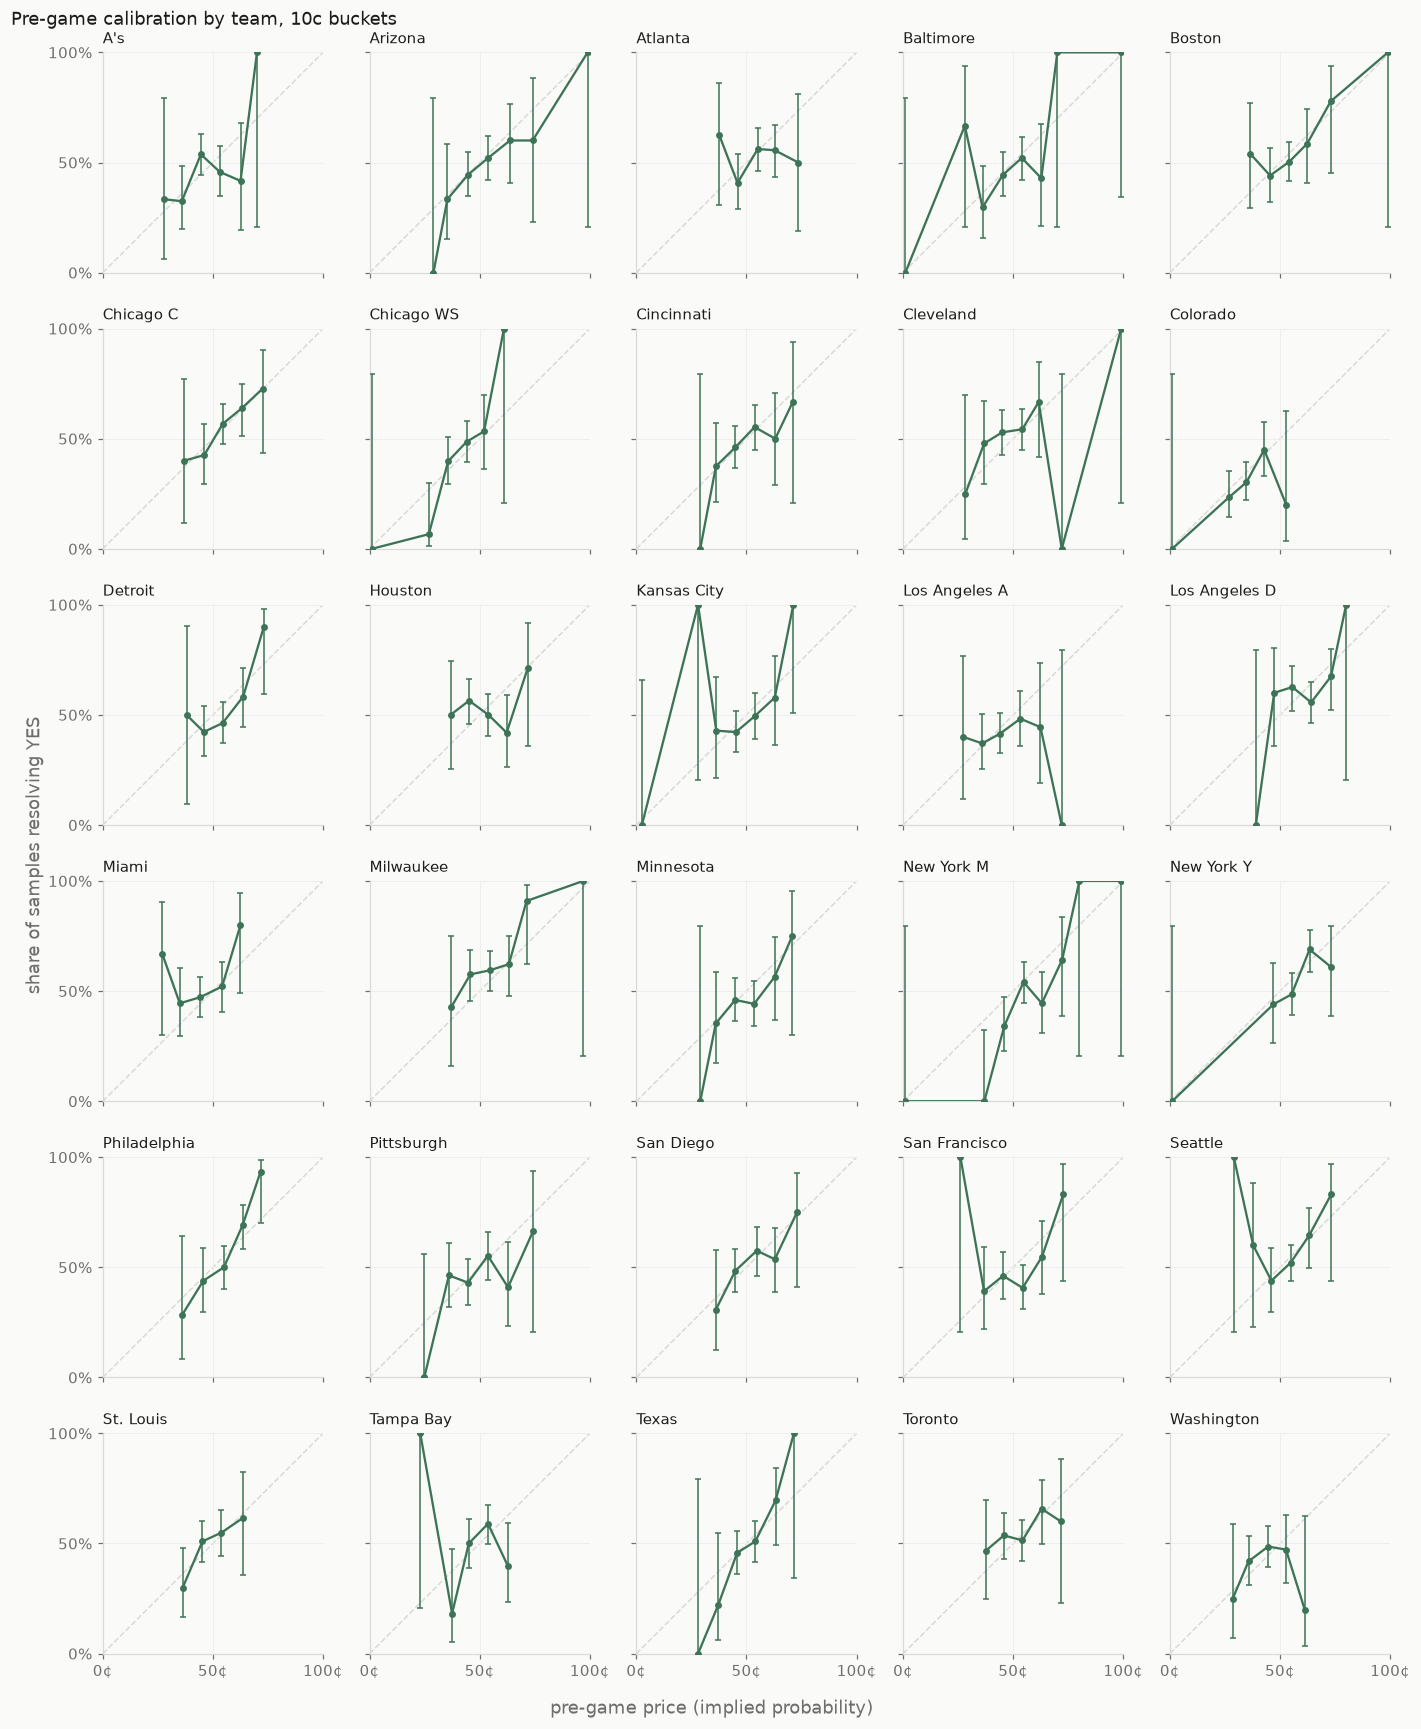

In [17]:
fig, axes = plt.subplots(6, 5, figsize=(13, 16), sharex=True, sharey=True)

for ax, team in zip(axes.flat, teams.sort("team")["team"]):
    df = calibration("mlb_calib_pre_snapshots", "team = ?", buckets=10,
                     params=[team])
    plot_calibration(ax, df)
    ax.set_title(team, color=INK, fontsize=10)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(CENTS)
    ax.yaxis.set_major_formatter(PCT)

fig.supxlabel("pre-game price (implied probability)", color=MUTED)
fig.supylabel("share of samples resolving YES", color=MUTED)
fig.suptitle("Pre-game calibration by team, 10c buckets", color=INK,
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

### Opportunities?

Anything that looks like it possibly could be miscalibrated has a small sample size, so I think it looks like markets are calibrated for each team.

## Cut 5 - Stability Over Time

If there are opportunities, do they persist through time?\
Maybe there used to be an opportunity but market players discovered it and now it no longer exists.\
So each season is split in half at its median game date, giving four periods.

1 datapoint per game from the home team.

In [18]:
con.sql("""
    CREATE OR REPLACE TEMP VIEW pre_snap_period AS
    SELECT game_pk, season, p, y, sched_start,
           CASE WHEN sched_start <= median(sched_start)
                    OVER (PARTITION BY season)
                THEN 'early' ELSE 'late' END AS half
    FROM pre_home
""")

PERIODS = [(2025, "early"), (2025, "late"), (2026, "early"), (2026, "late")]

con.sql("""
    SELECT season, half,
           min(sched_start)::DATE AS first_game,
           max(sched_start)::DATE AS last_game,
           count(*) AS n_samples
    FROM pre_snap_period
    GROUP BY season, half ORDER BY season, half
""").pl().select(
    pl.format("{} {}", pl.col("season"), pl.col("half")).alias("period"),
    pl.col("first_game"),
    pl.col("last_game"),
    fmt_count("n_samples").alias("samples"),
)

period,first_game,last_game,samples
"""2025 early""",2025-04-16,2025-07-08,"""1,103"""
"""2025 late""",2025-07-08,2025-11-01,"""1,100"""
"""2026 early""",2026-03-26,2026-05-14,"""652"""
"""2026 late""",2026-05-14,2026-07-03,"""652"""


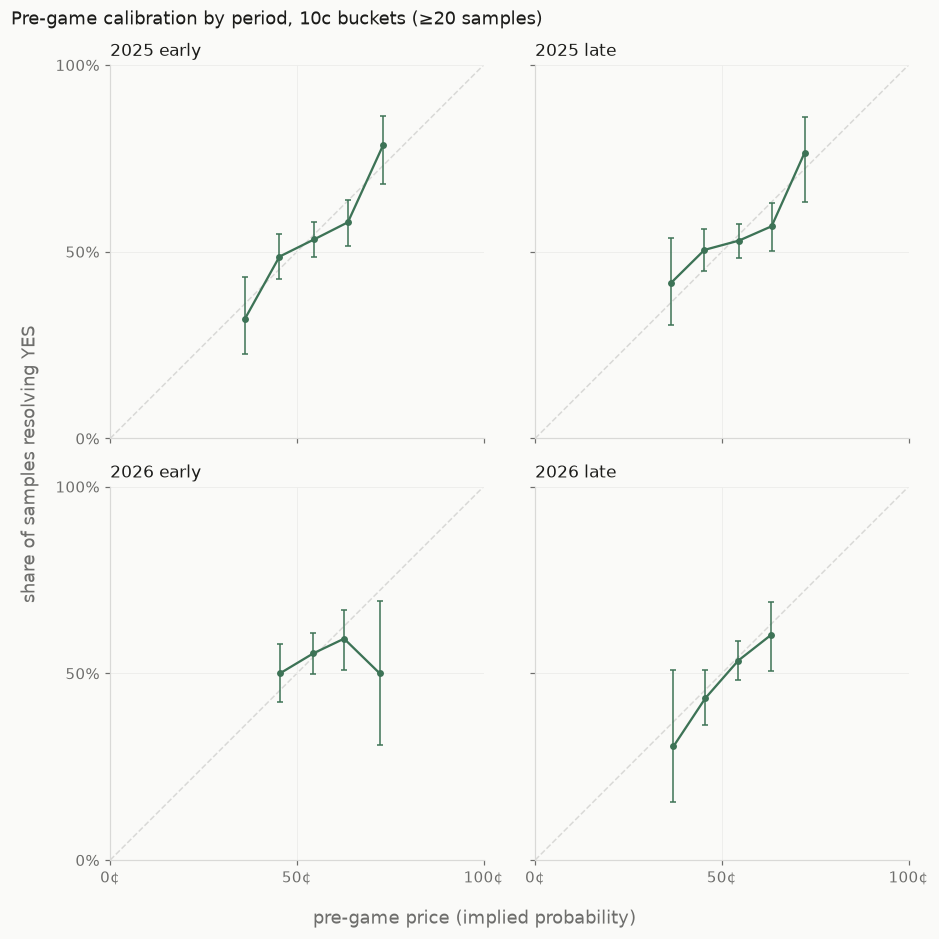

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(8.6, 8.6), sharex=True, sharey=True)

for ax, (season, half) in zip(axes.flat, PERIODS):
    df = calibration("pre_snap_period", "season = ? AND half = ?",
                     buckets=10, params=[season, half])
    plot_calibration(ax, df.filter(pl.col("n_samples") >= 20))
    ax.set_title(f"{season} {half}", color=INK, fontsize=11)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(CENTS)
    ax.yaxis.set_major_formatter(PCT)

fig.supxlabel("pre-game price (implied probability)", color=MUTED)
fig.supylabel("share of samples resolving YES", color=MUTED)
fig.suptitle("Pre-game calibration by period, 10c buckets (≥20 samples)",
             color=INK, x=0.01, ha="left")
fig.tight_layout()
plt.show()

### Opportunities?
Pre-game markets appear to be well calibrated across time.\
Note there is some variation between periods.

Note that this gives some evidence that the one significant bucket from Cut 1 is probably just noise.

## Cut 6 - Weather

Could weather cause pricing inefficiencies?
Perhaps a particular team performs worse in the heat/cold/rain and the market has not priced this in.

Note
- conditions are grouped: clear (Clear, Sunny), clouds (Partly Cloudy, Cloudy, Overcast), roof/dome (Roof Closed, Dome), rain (Rain, Drizzle)
- temperature and wind cuts only use outdoor games

In [20]:
con.sql("""
    CREATE OR REPLACE TEMP VIEW pre_snap_wx AS
    SELECT game_pk, p, y,
           CASE
               WHEN condition IN ('Clear', 'Sunny') THEN 'clear'
               WHEN condition IN ('Partly Cloudy', 'Cloudy', 'Overcast')
                   THEN 'clouds'
               WHEN condition IN ('Roof Closed', 'Dome') THEN 'roof/dome'
               WHEN condition IN ('Rain', 'Drizzle') THEN 'rain'
               ELSE 'other'
           END AS condition_group,
           temp_f,
           wind_mph
    FROM pre_home
""")


In [21]:
conditions = (group_deviation("pre_snap_wx", "condition_group")
              .rename({"grp": "condition"}))
show_group(conditions, "condition")

condition,avg price,win rate,win − price,95% CI (win − price),samples
"""clear""","""54.2¢""","""55.0%""","""+0.8¢""","""[-2.2¢, 3.8¢]""","""1,058"""
"""clouds""","""53.4¢""","""51.2%""","""-2.2¢""","""[-4.5¢, 0.1¢]""","""1,839"""
"""rain""","""55.0¢""","""45.2%""","""-9.9¢""","""[-25.9¢, 7.2¢]""","""31"""
"""roof/dome""","""53.4¢""","""56.3%""","""+2.9¢""","""[-1.2¢, 6.9¢]""","""579"""


In [22]:
temps = group_deviation("pre_snap_wx", """
    CASE WHEN temp_f < 60 THEN '< 60°F'
         WHEN temp_f < 70 THEN '60–69°F'
         WHEN temp_f < 80 THEN '70–79°F'
         ELSE '80°F+' END
""", "condition_group NOT IN ('roof/dome') AND temp_f IS NOT NULL",
    order_by="min(temp_f)").rename({"grp": "temperature (outdoor)"})
show_group(temps, "temperature (outdoor)")

temperature (outdoor),avg price,win rate,win − price,95% CI (win − price),samples
"""< 60°F""","""53.7¢""","""52.6%""","""-1.1¢""","""[-6.7¢, 4.4¢]""","""308"""
"""60–69°F""","""54.6¢""","""51.6%""","""-3.0¢""","""[-6.9¢, 0.8¢]""","""645"""
"""70–79°F""","""54.1¢""","""55.6%""","""+1.5¢""","""[-1.5¢, 4.5¢]""","""1,054"""
"""80°F+""","""52.7¢""","""49.6%""","""-3.0¢""","""[-6.3¢, 0.2¢]""","""921"""


In [23]:
winds = group_deviation("pre_snap_wx", """
    CASE WHEN wind_mph < 5 THEN '0–4 mph'
         WHEN wind_mph < 10 THEN '5–9 mph'
         ELSE '10+ mph' END
""", "condition_group NOT IN ('roof/dome') AND wind_mph IS NOT NULL",
    order_by="min(wind_mph)").rename({"grp": "wind (outdoor)"})
show_group(winds, "wind (outdoor)")

wind (outdoor),avg price,win rate,win − price,95% CI (win − price),samples
"""0–4 mph""","""54.0¢""","""53.3%""","""-0.7¢""","""[-5.0¢, 3.5¢]""","""527"""
"""5–9 mph""","""53.5¢""","""52.4%""","""-1.0¢""","""[-3.5¢, 1.5¢]""","""1,535"""
"""10+ mph""","""54.0¢""","""52.2%""","""-1.8¢""","""[-5.1¢, 1.6¢]""","""866"""


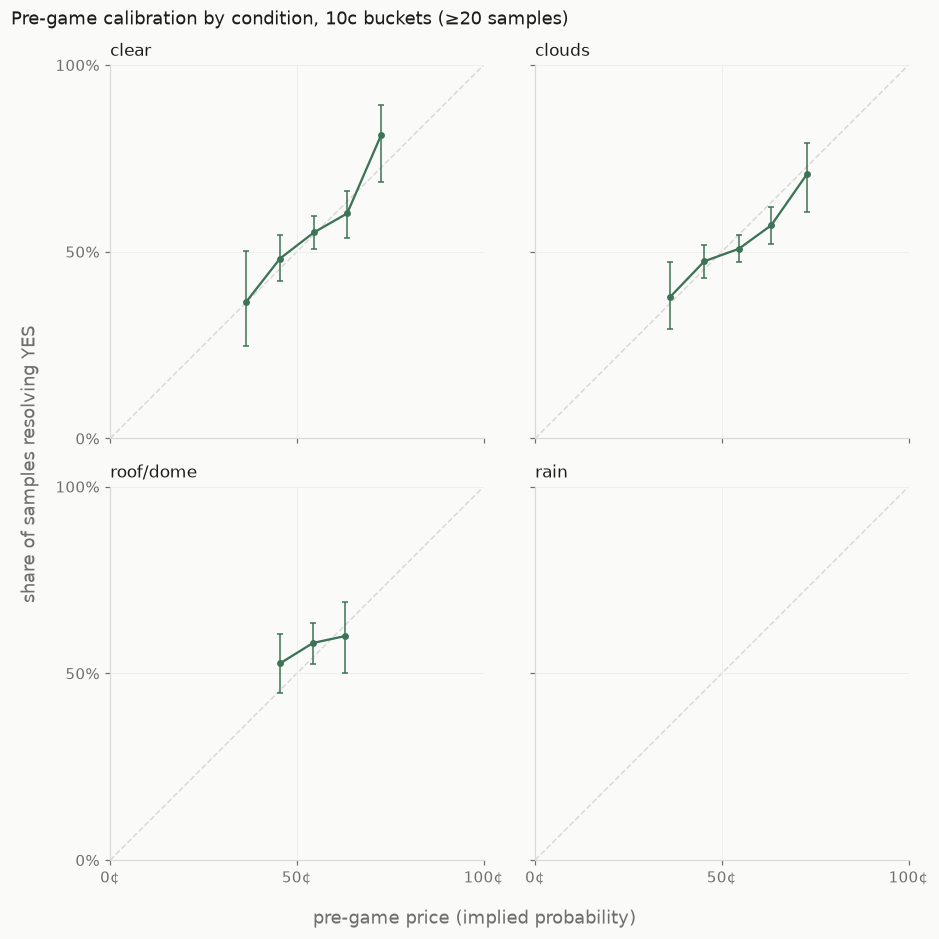

In [24]:
# home-side calibration curves per condition group
fig, axes = plt.subplots(2, 2, figsize=(8.6, 8.6), sharex=True, sharey=True)

for ax, grp in zip(axes.flat, ["clear", "clouds", "roof/dome", "rain"]):
    df = calibration("pre_snap_wx", "condition_group = ?", buckets=10,
                     params=[grp])
    plot_calibration(ax, df.filter(pl.col("n_samples") >= 20))
    ax.set_title(grp, color=INK, fontsize=11)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(CENTS)
    ax.yaxis.set_major_formatter(PCT)

fig.supxlabel("pre-game price (implied probability)", color=MUTED)
fig.supylabel("share of samples resolving YES", color=MUTED)
fig.suptitle("Pre-game calibration by condition, 10c buckets "
             "(≥20 samples)", color=INK, x=0.01, ha="left")
fig.tight_layout()
plt.show()

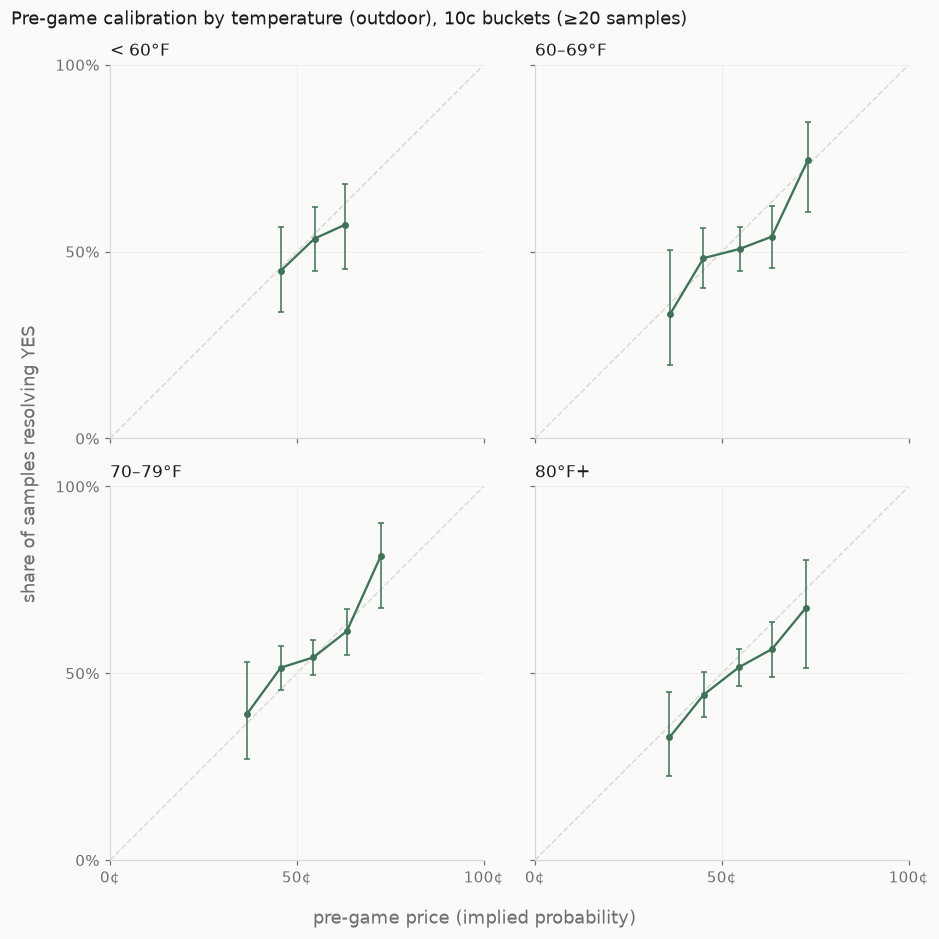

In [25]:
# outdoor games only, same bands as the temperature table
TEMP_BANDS = [
    ("< 60°F", "temp_f < 60"),
    ("60–69°F", "temp_f >= 60 AND temp_f < 70"),
    ("70–79°F", "temp_f >= 70 AND temp_f < 80"),
    ("80°F+", "temp_f >= 80"),
]

fig, axes = plt.subplots(2, 2, figsize=(8.6, 8.6), sharex=True, sharey=True)

for ax, (label, band) in zip(axes.flat, TEMP_BANDS):
    df = calibration("pre_snap_wx",
                     f"condition_group != 'roof/dome' AND {band}")
    plot_calibration(ax, df.filter(pl.col("n_samples") >= 20))
    ax.set_title(label, color=INK, fontsize=11)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(CENTS)
    ax.yaxis.set_major_formatter(PCT)

fig.supxlabel("pre-game price (implied probability)", color=MUTED)
fig.supylabel("share of samples resolving YES", color=MUTED)
fig.suptitle("Pre-game calibration by temperature (outdoor), 10c buckets "
             "(≥20 samples)", color=INK, x=0.01, ha="left")
fig.tight_layout()
plt.show()

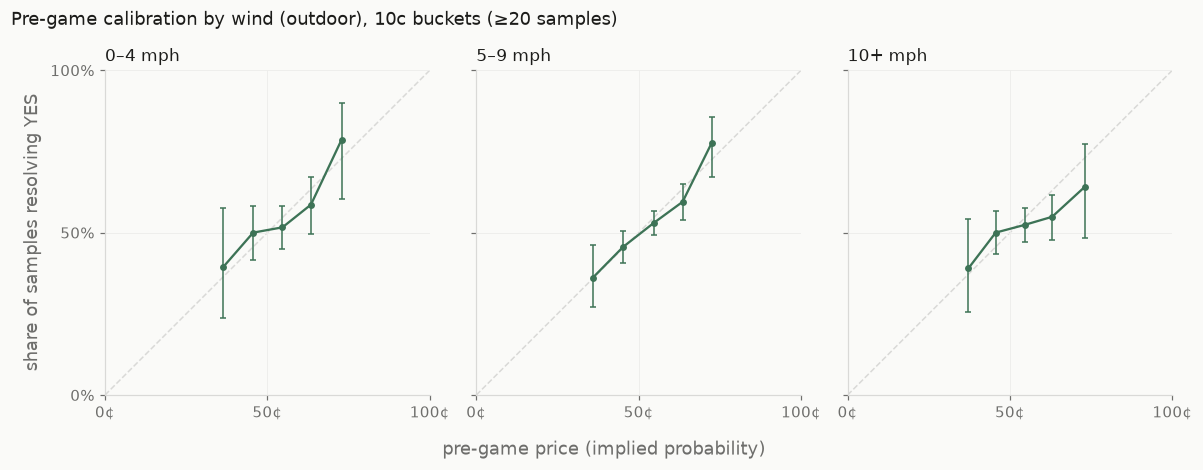

In [26]:
# outdoor games only, same bands as the wind table
WIND_BANDS = [
    ("0–4 mph", "wind_mph < 5"),
    ("5–9 mph", "wind_mph >= 5 AND wind_mph < 10"),
    ("10+ mph", "wind_mph >= 10"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), sharex=True, sharey=True)

for ax, (label, band) in zip(axes.flat, WIND_BANDS):
    df = calibration("pre_snap_wx",
                     f"condition_group != 'roof/dome' AND {band}")
    plot_calibration(ax, df.filter(pl.col("n_samples") >= 20))
    ax.set_title(label, color=INK, fontsize=11)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.xaxis.set_major_formatter(CENTS)
    ax.yaxis.set_major_formatter(PCT)

fig.supxlabel("pre-game price (implied probability)", color=MUTED)
fig.supylabel("share of samples resolving YES", color=MUTED)
fig.suptitle("Pre-game calibration by wind (outdoor), 10c buckets "
             "(≥20 samples)", color=INK, x=0.01, ha="left")
fig.tight_layout()
plt.show()

### Opportunities
No weather group deviates significantly.\
Perhaps in games with 10+mph winds priced above 60c there is 

## Costs - Calibrated vs Exploitable

A deviation is only interesting if it survives the cost of trading it.\
Exploiting one means buying the underpriced side as a taker and holding to settlement (settlement is free).\
The cost
- taker fee: 7c × p × (1−p) per contract
- approximately half the bid-ask spread (Appendix C)

That comes to about 2.2c in the mid-range where MLB games trade before the game starts.

## Findings

**In-game prices are well calibrated.**\
Across the nine entering-inning tables, 5 of 86 buckets' CIs exclude zero, roughly the false-positive rate of 95% intervals, with no pattern in where they land.\
Entering extras is the thinnest slice (302 samples) and shows nothing significant.

**No team stands out beyond chance.**\
Two of thirty teams' deviation intervals exclude zero (Milwaukee +6.4c, New York M -8.2c).\
At 95% confidence, that is roughly what noise produces across thirty tests.

**Home/away shows no aggregate bias.**\
Home -0.5c and away -0.6c, neither significant.\
An earlier volume-weighted per-trade version of this analysis flagged home mid-range markets as significantly overpriced. That result did not survive the switch to one observation per market. A caution against reading too much into any single cut here.

**The pre-game compression pattern is judged noise.**\
The bucket view flags one bucket: 60-70c favorites at -5.1c.\
Reasons to distrust it
- the bucket boundaries were chosen after looking
- ~10 buckets were tested, so one exclusion is close to the false-positive rate
- with costs netted (below), even the face-value effect is untradeable

The project verdict: noise.

**Weather shows no pricing effect.**\
Deviations by condition group (clear, clouds, roof/dome, rain), temperature band, and wind speed all have CIs that include zero. Eleven intervals, none significant.\
The rain group is 31 games and says nothing either way.

**Costs beat the deviations.**\
Netting the taker fee plus half the one-tick spread (~2.2c in the mid-range) against the curve, no bucket's CI clears the cost band — the only significant bucket (60-70c) has a CI near edge of -1.6c against a ~2.1c cost.

## Appendix A - No-Arbitrage Check

Each game has two markets, one per team, each with its own order book.\
If the books are consistent the two pre-game snapshots should sum to $1.

They do. The median of p_home + p_away is ~1.01c\
73% of games land within 2c of $1\
and only 16 of 3,507 land beyond 5c.

So the away market is the home market's mirror and carries no extra information.
The analysis keeps the home side.\
Note
- the two snapshots are last trades from two separate books, possibly minutes apart, and each prints at its book's bid or ask. A cent or two of slack is expected, and a stale leg explains sums further out
- a fat tail far from $1 would have been a finding in its own right (free arbitrage).
    - 16 games of 3,507 is not one

In [33]:
totals = con.sql("""
    SELECT game_pk, sum(p) AS total
    FROM mlb_calib_pre_snapshots
    GROUP BY game_pk
    HAVING count(*) = 2
""")
con.sql("""
    SELECT count(*) AS n_games,
           median(total) AS med_total,
           count(*) FILTER (abs(total - 1) <= 0.01) AS within_1c,
           count(*) FILTER (abs(total - 1) <= 0.02) AS within_2c,
           count(*) FILTER (abs(total - 1) > 0.05) AS beyond_5c,
           min(total) AS min_total,
           max(total) AS max_total
    FROM totals
""").pl().select(
    fmt_count("n_games").alias("games with both snapshots"),
    fmt_cents("med_total").alias("median p_home + p_away"),
    fmt_count("within_1c").alias("within 1¢ of $1"),
    fmt_count("within_2c").alias("within 2¢"),
    fmt_count("beyond_5c").alias("beyond 5¢"),
    fmt_cents("min_total").alias("min"),
    fmt_cents("max_total").alias("max"),
)

games with both snapshots,median p_home + p_away,within 1¢ of $1,within 2¢,beyond 5¢,min,max
"""3,507""","""101.0¢""","""537""","""2,566""","""16""","""96.5¢""","""118.0¢"""


## Appendix B - Snapshot Freshness

How old is the pre-game snapshot at first pitch?

It's fairly fresh\
- median: age 1 minute
- 90th percentile: 5 minutes
- 99th: 29 minutes.

Every game has a home-side trade inside the 24 hour window.\
So the exact definition of "shortly before the game" shouldn't make much of a difference.\
How much could available info possibly change in the 30 mins leading up to the game?

In [34]:
con.sql("""
    SELECT count(*) AS n_snapshots,
           (SELECT n_games FROM mlb_calib_build_info) - count(*)
               AS n_missing,
           quantile_cont(mins, 0.5) AS median_mins,
           quantile_cont(mins, 0.9) AS p90_mins,
           quantile_cont(mins, 0.99) AS p99_mins
    FROM (
        SELECT date_diff('minute', created_time, sched_start) AS mins
        FROM pre_home
    )
""").pl().select(
    fmt_count("n_snapshots").alias("pre-game snapshots"),
    fmt_count("n_missing").alias("games with no trade in window"),
    pl.format("{} min", pl.col("median_mins").cast(pl.Int64))
        .alias("median age at first pitch"),
    pl.format("{} min", pl.col("p90_mins").cast(pl.Int64)).alias("p90"),
    pl.format("{} min", pl.col("p99_mins").cast(pl.Int64)).alias("p99"),
)

pre-game snapshots,games with no trade in window,median age at first pitch,p90,p99
"""3,507""","""0""","""1 min""","""5 min""","""29 min"""


## Appendix C - Effective Spread Check

Trades occur at the bid or the ask, never in between.\
A taker buying YES prints at the ask\
a taker selling YES prints at the bid.

So if spreads were wide,\
a last-trade snapshot could sit up to half a spread away from the market's actual estimate,\
and that alone could look like miscalibration.

Is that happening here?

For each game take the last taker-bought-YES print (the ask)\
and the last taker-sold-YES print (the bid)\
on the home team's market in the pre-game window.\
The gap between them is a proxy for the spread.

The spread is basically one cent
- median gap: 1c
- 90th percentile: 2c
- only 92 of 3,392 games above 3c

So the last trade sits at most about half a cent from where the market actually is.\
That half cent is the half-spread the Costs section charges.\
Note
- the two legs can be minutes apart, so if the market moved in between the gap can come out zero or negative

In [30]:
con.sql("""
    CREATE OR REPLACE TEMP VIEW spread_legs AS
    SELECT game_pk,
           max(p) FILTER (taker_outcome_side = 'yes') AS ask_proxy,
           max(p) FILTER (taker_outcome_side = 'no') AS bid_proxy
    FROM (
        SELECT game_pk, p, taker_outcome_side, created_time
        FROM mlb_calib_pre_window_trades
        WHERE side = 'home'
        QUALIFY row_number() OVER (
            PARTITION BY game_pk, taker_outcome_side
            ORDER BY created_time DESC) = 1
    )
    GROUP BY game_pk
""")

con.sql("""
    SELECT count(*) AS n_games,
           count(gap) AS n_both_sides,
           median(gap) AS med_gap,
           quantile_cont(gap, 0.9) AS p90_gap,
           count(*) FILTER (gap > 0.03) AS n_wide,
           count(*) FILTER (gap < 0) AS n_crossed
    FROM (SELECT ask_proxy - bid_proxy AS gap FROM spread_legs)
""").pl().select(
    fmt_count("n_games").alias("games"),
    fmt_count("n_both_sides").alias("both sides traded"),
    fmt_cents("med_gap").alias("median gap"),
    fmt_cents("p90_gap").alias("p90 gap"),
    fmt_count("n_wide").alias("gap > 3¢"),
    fmt_count("n_crossed").alias("gap < 0 (market moved)"),
)

games,both sides traded,median gap,p90 gap,gap > 3¢,gap < 0 (market moved)
"""3,507""","""3,392""","""1.0¢""","""2.0¢""","""92""","""48"""
